#  Computation of BOP Features

- input: atoms objects
- output here: all the descriptors comming from BOP (averages, atomic site based, etc)

#  Calculation of features from available libraries

- input curated BS

# TODO
- [X] Calculate site specific averages
- [ ] Distributions of descriptors / characterization of descriptors

In [1]:
import os
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer, BopfoxFeatures
import pandas as pd

## options:

In [2]:
dataset = 'Cr-Co-W'
atomsobjectloc = os.path.join(dataset, 'Atomsobjects')
components = dataset.replace('-','')
models = ['canonical','projections', 'projections_os']
cutoff = 'table'
atoms = 'initial'
moments = 16

In [3]:
# only loop over the models
atomspickle =  os.path.join(atomsobjectloc, f'{components}-sorted-POSCAR-{atoms}-rescaled-AtomsObjects.pkl')
AtomsObjects = pd.read_pickle(atomspickle).dropna(how='any')

In [4]:
results = {}
resultspickle = {}
for model in models:
    modelsfile = os.path.join('models', f'{components}_{model}.bx')
    print('atoms: ', atoms, 'model: ', model, '  cutoff: ', cutoff, ' moments:', moments)
    resultspickle[model] = os.path.join(dataset, 'Descriptors', f'{components}_{atoms}_{model}_{cutoff}_WUBIND_{moments}.pkl')
    BOPC = BopfoxFeatures(
            AtomsObjects['atoms'],modelsfile, modelname=model,
            cutoffby=cutoff, 
            binary = '/home/storage/fortimtb/CuadernoTrabajo/oldrepobopfox/src/bopfox_mpi',
            moments = moments
            )
    BOPC.calculate_bop_forall(ForceKeepSpecies=True,
            input_pickle = resultspickle[model]
            )
    results[model] = BOPC.RESULTS

atoms:  initial model:  canonical   cutoff:  table  moments: 16


  0%|          | 0/1681 [00:00<?, ?it/s] 

atoms:  initial model:  projections   cutoff:  table  moments: 16


  0%|          | 0/1681 [00:00<?, ?it/s] 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None
return None


# Failed BOP Calculations 

In [5]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind               0
U_bond_atom          0
U_bond_atom_list     0
moments             18
normed_moments       0
an                   0
bn                   0
sigma                0
Ainf                 0
Binf           

##  remove bad data

In [6]:
removenans = [result.dropna(inplace=True) for model, result in results.items()]

In [7]:
for model, result in results.items():
    print(f'{model} model:')
    print(result.isna().sum())
    print(result[result.isna().any(axis=1)])
    print('=================')

canonical model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dtype: int64
Empty DataFrame
Columns: [U_bind, U_bond_atom, U_bond_atom_list, moments, normed_moments, an, bn, sigma, Ainf, Binf]
Index: []
projections_os model:
U_bind              0
U_bond_atom         0
U_bond_atom_list    0
moments             0
normed_moments      0
an                  0
bn                  0
sigma               0
Ainf                0
Binf                0
dt

In [8]:
for (model, resultpckl), result in zip(resultspickle.items(), results.values()):
    result.to_pickle(resultpckl)

# Arrangement and averaging BOP Features 

In [9]:
from Tools.DatasetTools import GeneralFeaturizer as gf

In [10]:
descriptorlocation = os.path.join(dataset, 'Descriptors' )

In [11]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'pyscal_steinhardt.kpl')

In [12]:
PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)

In [13]:
from importlib.machinery import SourceFileLoader
gf = SourceFileLoader('gf', 'Tools/DatasetTools/GeneralFeaturizer.py').load_module()

In [14]:
import pdb

In [17]:
resultscnav = {}
specialcolumns =['U_bind','U_bond_atom', 'U_bond_atom_list'] 
for model, result in results.items():
    columnstoexpand = result.columns.drop(specialcolumns)
    df = gf.array_expansions(result, columnstoexpand)
    ThisCoordination = PyscalFeatures.pyscal_cn[result.index]
    resultscnav[model] = gf.featurize_dataframe(df, ThisCoordination)
    resultscnav[model] = pd.concat([result[specialcolumns[:-1]], resultscnav[model]],  axis=1)
    averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(resultspickle[model]))
    resultscnav[model].to_pickle(averaged_bop_file)

In [18]:
resultscnav['canonical']

,U_bind,U_bond_atom,moments_1_0,moments_1_CN12,moments_1_CN13,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,...,Ainf_1_CN13,Ainf_1_CN14,Ainf_1_CN15,Ainf_1_CN16,Binf_1_0,Binf_1_CN12,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16
Co_pv6W_sv6.C14-BBA.FM,-58.644616,-78.588438,2.496405,2.061708,0.000000,0.000000,0.000000,0.434697,-0.957307,-0.745905,...,0.000000,0.000000,0.000000,-0.097097,2.071102,1.394808,0.000000,0.000000,0.000000,0.676294
Co_pv6W_sv6.C14-BBA.NM,-58.644616,-78.588438,2.496405,2.061708,0.000000,0.000000,0.000000,0.434697,-0.957307,-0.745905,...,0.000000,0.000000,0.000000,-0.097097,2.071102,1.394808,0.000000,0.000000,0.000000,0.676294
Cr_pv6W_sv2.D0_19-A3B.FM,-42.039279,-42.05443,1.530625,1.530625,0.000000,0.000000,0.000000,0.000000,-0.453207,-0.453207,...,0.000000,0.000000,0.000000,0.000000,1.389247,1.389247,0.000000,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,-42.039279,-42.05443,1.530625,1.530625,0.000000,0.000000,0.000000,0.000000,-0.453207,-0.453207,...,0.000000,0.000000,0.000000,0.000000,1.389247,1.389247,0.000000,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,-143.858275,-177.797933,1.797828,0.663849,0.000000,0.945488,0.188491,0.000000,-0.577710,-0.213980,...,0.000000,-0.075419,-0.018909,0.000000,1.530076,0.508984,0.000000,0.817739,0.203353,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,-73.831298,-74.435034,1.828545,1.308482,0.000000,0.197531,0.143759,0.178772,-0.599148,-0.426060,...,0.000000,-0.029424,-0.043432,-0.033096,1.764447,0.965134,0.000000,0.263546,0.268330,0.267437
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,-156.777732,-172.917606,1.713707,0.632789,0.000000,0.901248,0.179671,0.000000,-0.537641,-0.199138,...,0.000000,-0.073633,-0.018462,0.000000,1.493851,0.496933,0.000000,0.798379,0.198539,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,-156.777732,-172.917606,1.713707,0.632789,0.000000,0.901248,0.179671,0.000000,-0.537641,-0.199138,...,0.000000,-0.073633,-0.018462,0.000000,1.493851,0.496933,0.000000,0.798379,0.198539,0.000000
Co_pv13W_sv16.chi-ABAB.NM,-127.090687,-186.802107,2.241933,0.000000,0.838303,0.000000,0.000000,0.266543,-0.751986,0.000000,...,-0.075585,0.000000,0.000000,-0.038985,1.611500,0.000000,0.626761,0.000000,0.000000,0.258547


# Characterization of BOP features 

In [19]:
import re

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,8))
plt.rc('font', size=22)

<AxesSubplot:>

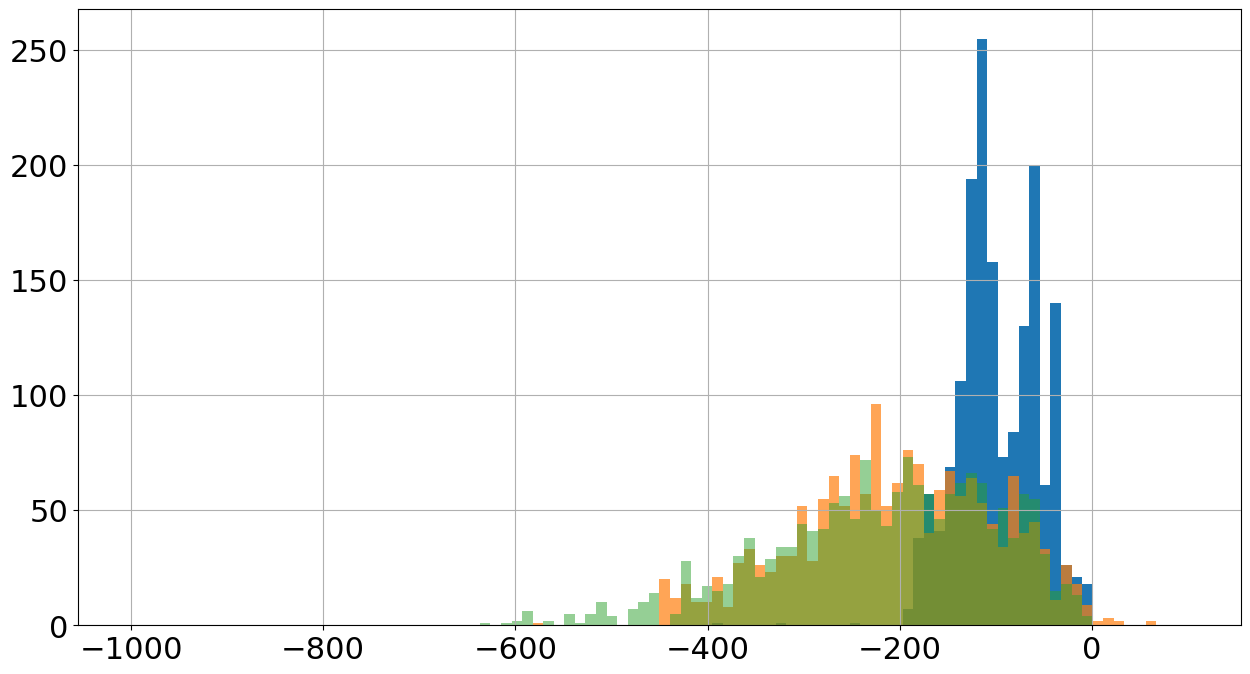

In [34]:
ax = resultscnav['canonical']['U_bind'].hist(bins=100, range=[-1000,100])
resultscnav['projections']['U_bind'].hist(bins=100, ax=ax, alpha=0.7, range=[-1000,100])
resultscnav['projections_os']['U_bind'].hist(bins=100, ax=ax, alpha=0.5,range=[-1000,100])

In [52]:
def comparefeatures(featurename, featuresymbol):
    plotfeature = {f'{featurename}_{i}_0': fr'$\langle {featuresymbol}_{i} \rangle $' for i in range(1,4)}
    nplots = len(plotfeature)
    fig = plt.figure(figsize=(7*nplots, 5))
    ax = fig.subplots(1, nplots, sharey=True)
    ensamble = []
    for thisresultcnav, thisname in zip(resultscnav.values(), plotfeature.keys()):
        ensamble.append(thisresultcnav[thisname] )
    ensamble = pd.concat(ensamble, axis=0)
    thisrange = [ensamble.min(), ensamble.max()]
    for i, (feature, title) in enumerate(plotfeature.items()):
        ax[i].set_xlabel(title)
        for model, result in resultscnav.items():
            ax[i].hist(result[feature], density=True, bins=100, alpha=0.81, edgecolor='k', label=model, range=thisrange)
    ax[-1].legend()
    ax[0].set_ylabel('Counts')
    fig.tight_layout()

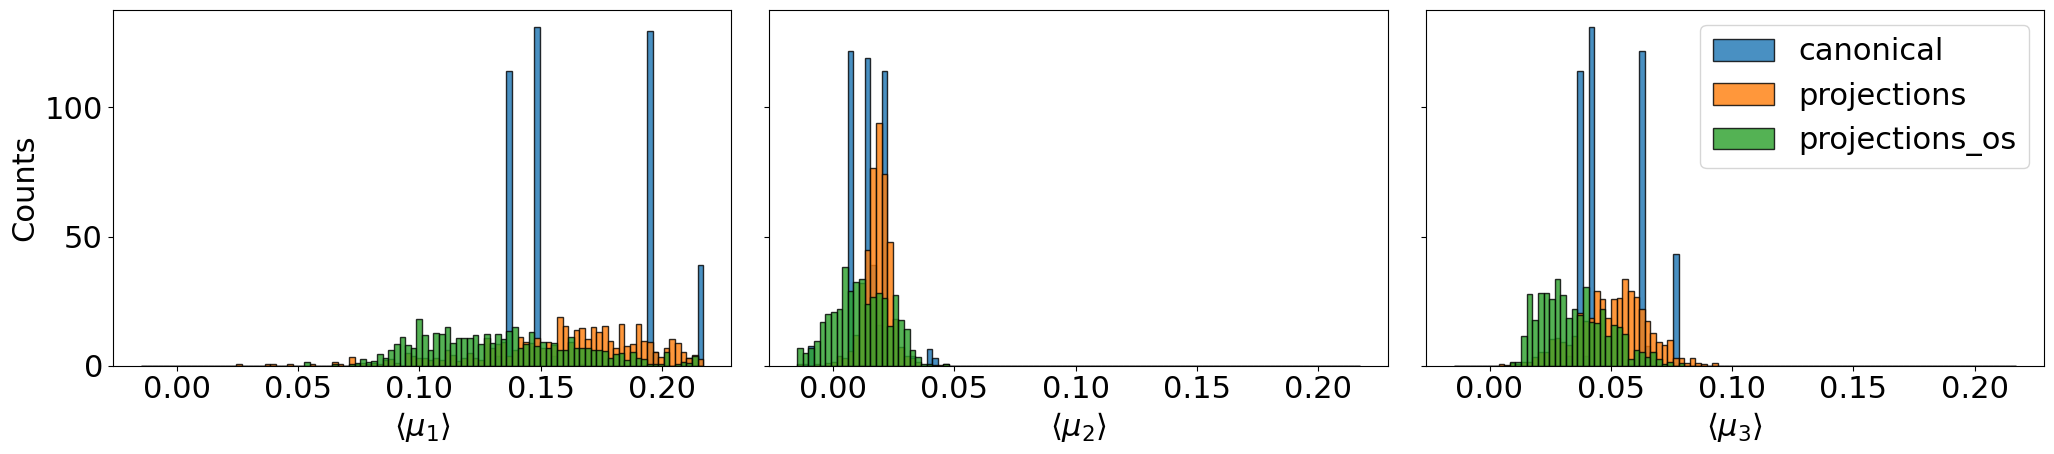

In [53]:
comparefeatures('normed_moments','\mu')

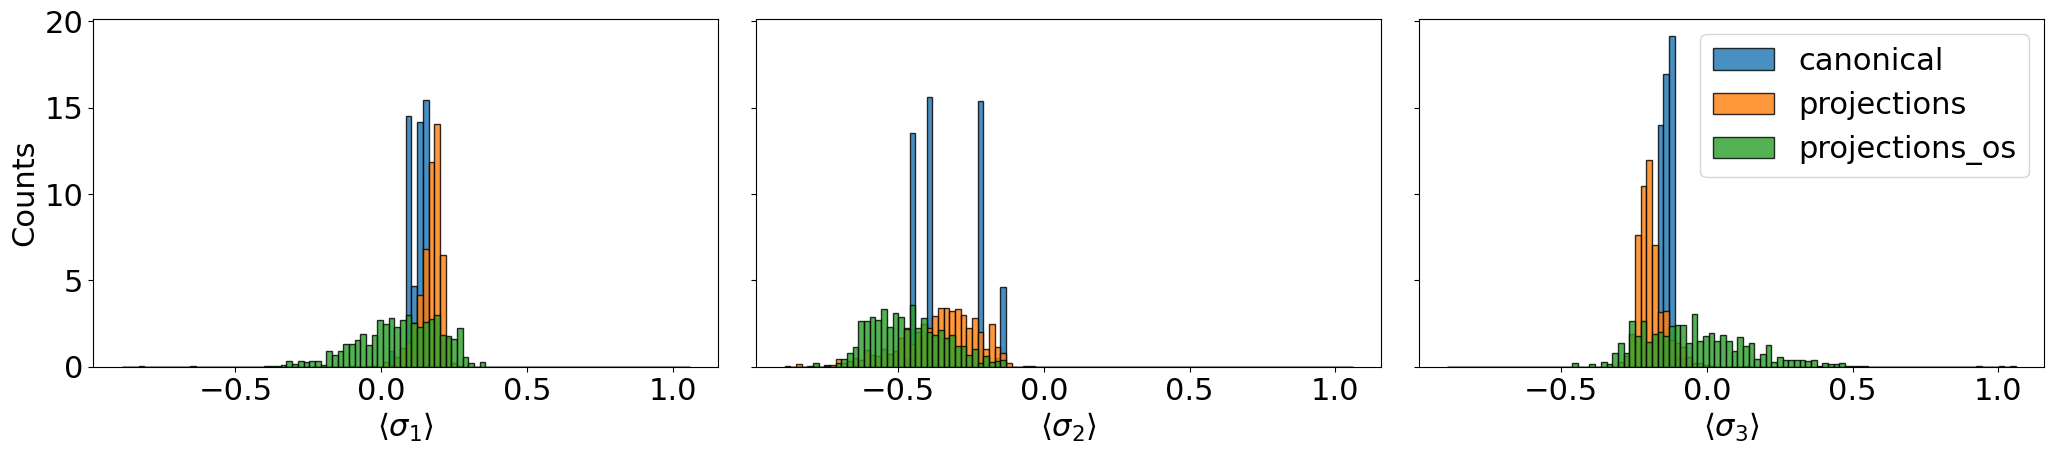

In [54]:
comparefeatures('sigma', '\sigma')

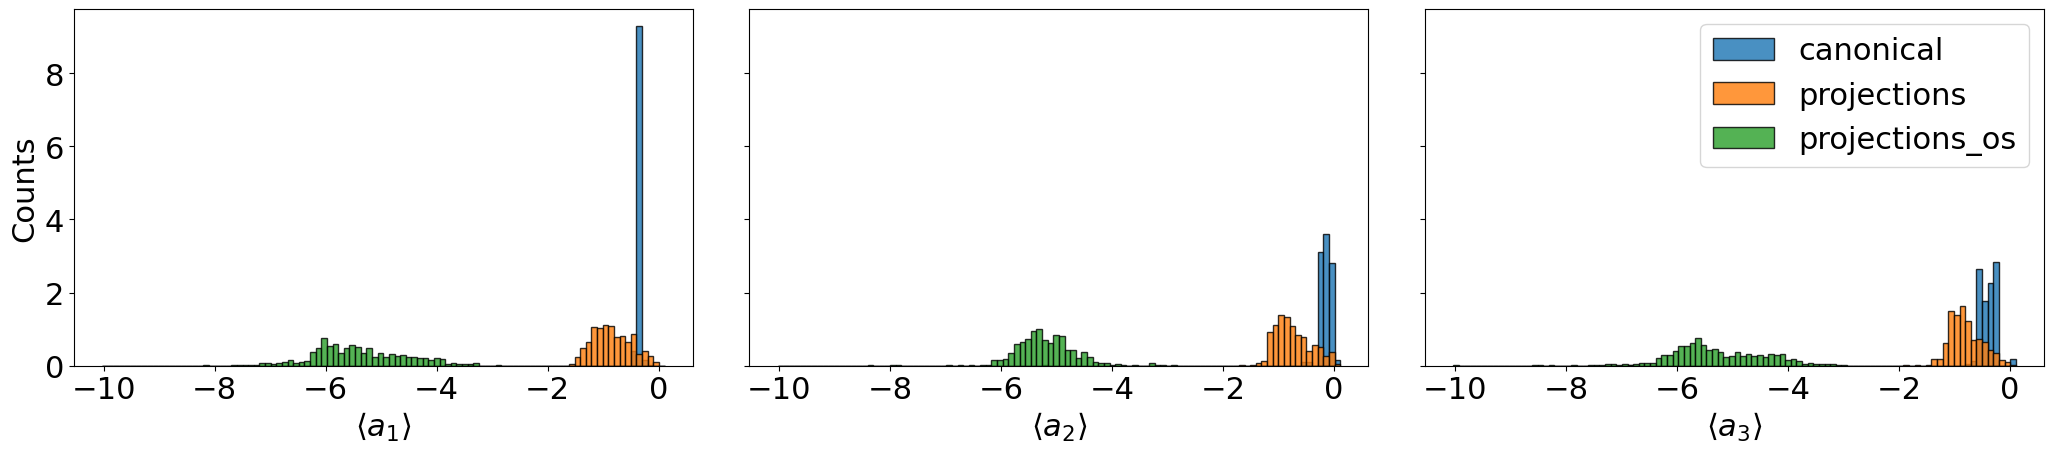

In [55]:
comparefeatures('an', 'a')

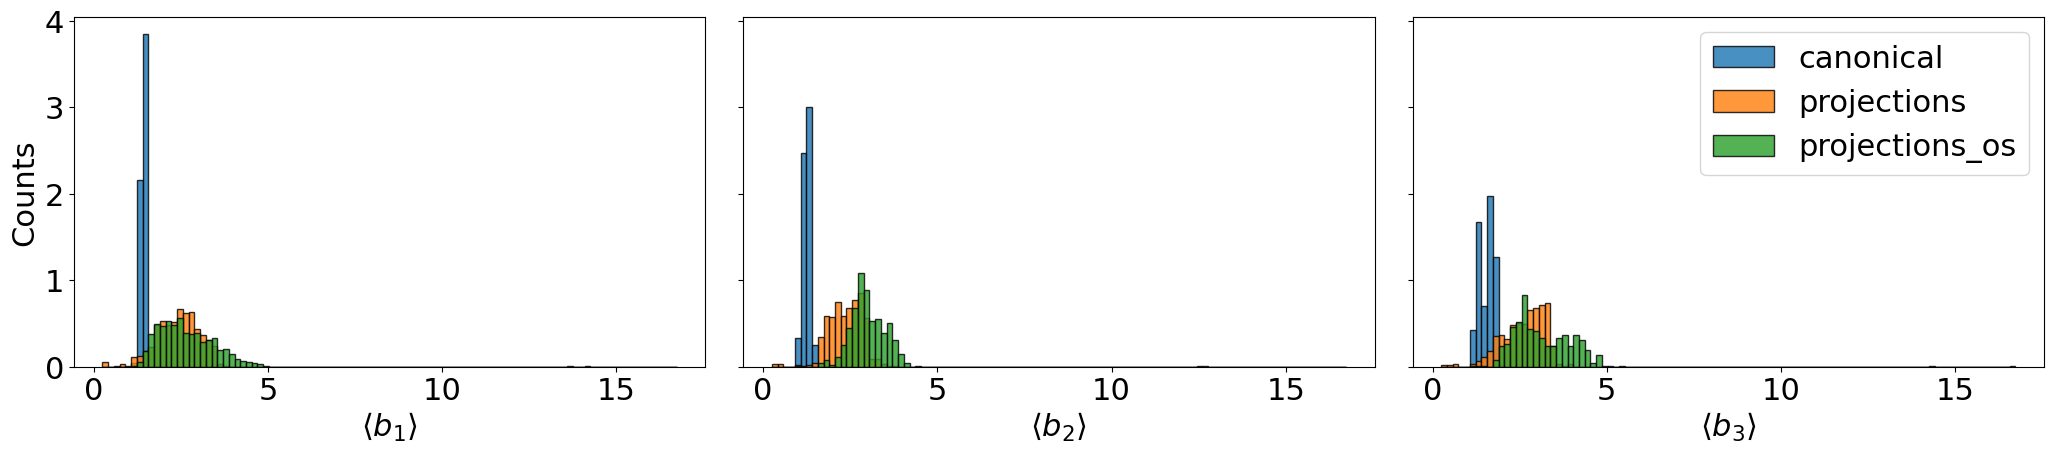

In [56]:
comparefeatures('bn', 'b')

In [57]:
CP = ['0', 'CN12', 'CN13', 'CN14','CN15','CN16']
CPSYMB=['_{0}',  '{CN_{12}}', '{CN_{13}}', '{CN_{14}}','{CN_{15}}','{CN_{16}}']

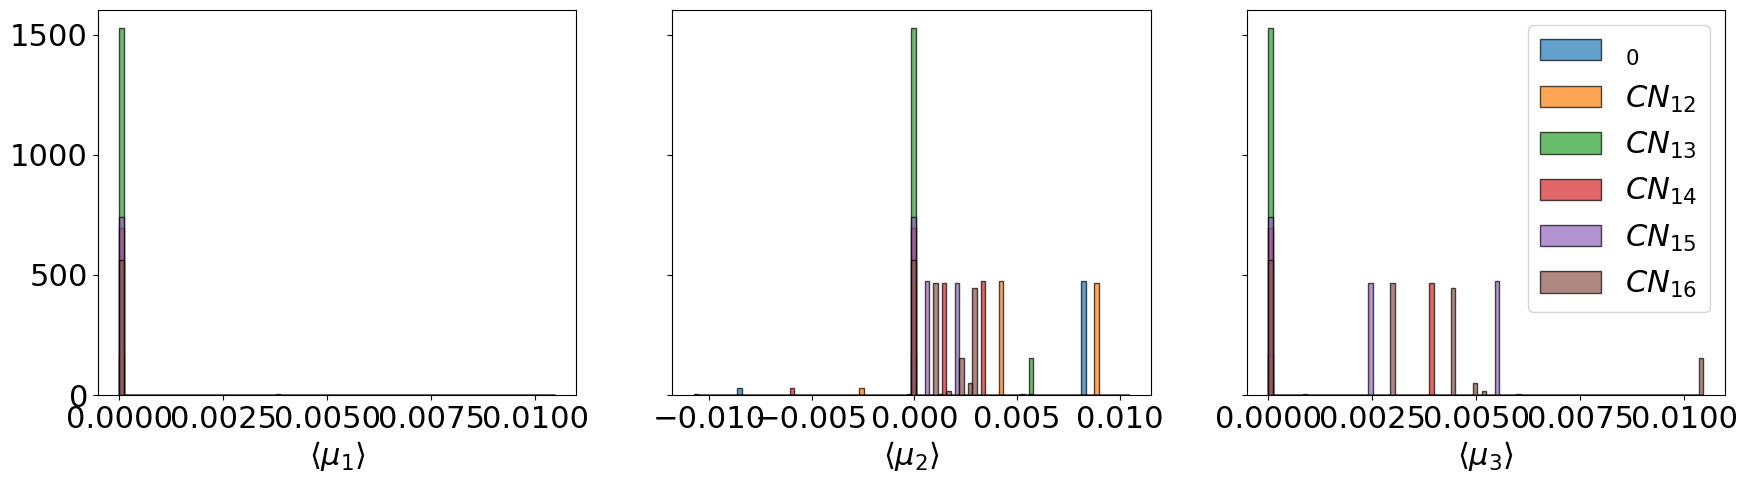

In [78]:
featurename = 'normed_moments'
featuresymbol = '\mu'
fig, ax = plt.subplots(1,3, figsize = (21,5), sharey=True)
for i, tax in enumerate(ax):
    for case, symbol in zip(CP,CPSYMB):
        featuremain = fr'{featurename}_{i+1}' 
        featurecol = fr'{featuremain}_{case}'
        featuretitle = fr'$\langle {featuresymbol}_{i+1} \rangle$'
        tax.set_xlabel(featuretitle)
        thismin = resultscnav['canonical'].filter(regex=featuremain+'_').min().min()
        thismaxn = resultscnav['canonical'].filter(regex=featuremain+'_').max().max()
    #     = fr'${featuresymbol}_{i} $' for i in range(1,4)}
        tax.hist(resultscnav['canonical'][f'{featurecol}'], label=f'${symbol}$',bins=100, edgecolor='k', alpha=0.7, range=[thismin, thismax])
ax[-1].legend()

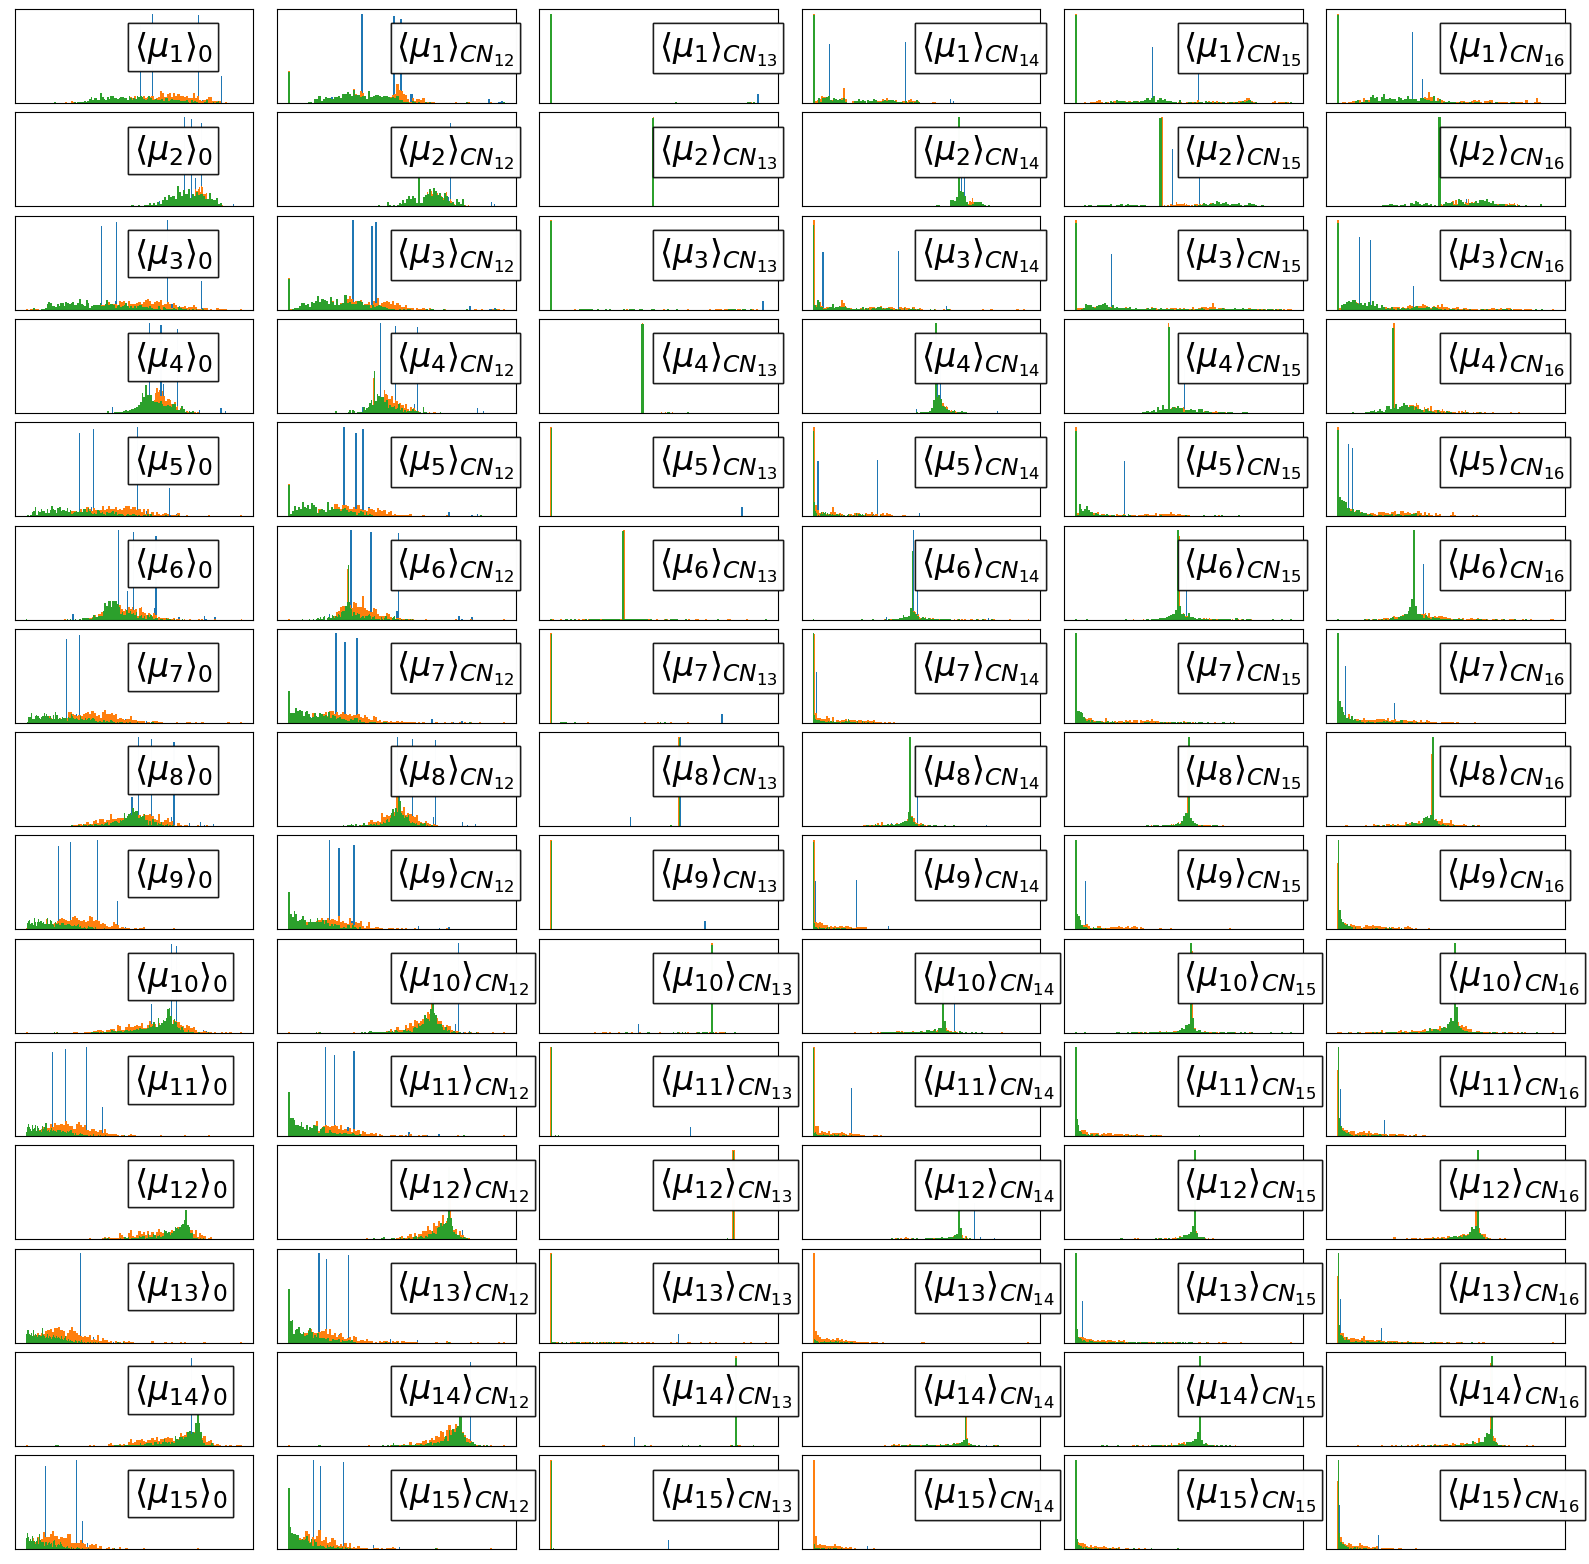

In [79]:
tl = SourceFileLoader('tl', 'Tools/DatasetTools/Tools.py').load_module()
plotter = tl.Plotting
selection = resultscnav['canonical'].columns.str.contains('normed_moments')
normedmomentnames = resultscnav['canonical'].columns[selection]
normedmomenttitles = pd.Series({name: re.sub('normed_moments_(.*)_',r'$\\langle \\mu_{\1} \\rangle ', name)+'$' for name in normedmomentnames})
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' 0\$','_{0}$', s))
normedmomenttitles = normedmomenttitles.map(lambda s: re.sub(' CN(.*)\$','_{CN_{\\1}}$', s))
fig, ax = plotter.histoff_realfeatures(resultscnav['canonical'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6)
fig, ax = plotter.histoff_realfeatures(resultscnav['projections'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))
fig, ax = plotter.histoff_realfeatures(resultscnav['projections_os'],normedmomentnames,normedmomenttitles,(20,20), ncols = 6, fig_ax=(fig, ax))